In [1]:
import pathlib

import joblib
import numpy as np
import pandas as pd

In [2]:
train_test_wells_path = pathlib.Path(
    "../data_splits/train_test_wells.parquet"
).resolve()


profile_data_path = pathlib.Path(
    "../../data/CP_scDINO_features/combined_CP_scDINO_norm_fs_aggregated.parquet"
).resolve()
terminal_column_names = pathlib.Path("../results/terminal_columns.txt").resolve(
    strict=True
)
terminal_column_names = [
    line.strip() for line in terminal_column_names.read_text().splitlines()
]
all_features_model = pathlib.Path(
    "../models/train_elastic_net_all_annexinv_features_model.joblib"
).resolve()
single_feature_model = pathlib.Path(
    "../models/train_elastic_net_single_terminal_features_model.joblib"
).resolve()
all_shuffled_features_model = pathlib.Path(
    "../models/train_shuffled_elastic_net_all_annexinv_features_model_shuffled.joblib"
).resolve()
single_shuffled_features_model = pathlib.Path(
    "../models/train_shuffled_elastic_net_single_terminal_features_model_shuffled.joblib"
).resolve()
df = pd.read_parquet(profile_data_path)

In [3]:
model = joblib.load(single_feature_model)
model.coef_

# get coefficients for each feature
feature_names = model.feature_names_in_
coefficients = model.coef_

coefs_df = pd.DataFrame({"feature": feature_names, "coefficient": coefficients})
# get the top 5 and bottom 5 features
coefs_df["abs_coefficient"] = coefs_df["coefficient"].abs()
coefs_df.sort_values("abs_coefficient", ascending=False, inplace=True)
coefs_df

,feature,coefficient,abs_coefficient
298,Cytoplasm_Correlation_K_CL_561_CL_488_2_CP,0.085800,0.085800
65,Cells_Intensity_LowerQuartileIntensity_CL_488_...,0.035740,0.035740
74,Cells_Intensity_MeanIntensityEdge_CL_561_CP,-0.020895,0.020895
521,Nuclei_Correlation_Costes_DNA_CL_561_CP,0.001132,0.001132
1555,channel488-2_cls_feature_89_scDINO,-0.000000,0.000000
...,...,...,...
781,Nuclei_Texture_Correlation_CL_488_1_3_01_256_CP,0.000000,0.000000
782,Nuclei_Texture_Correlation_CL_488_1_3_02_256_CP,0.000000,0.000000
783,Nuclei_Texture_Correlation_CL_488_1_3_03_256_CP,0.000000,0.000000
784,Nuclei_Texture_Correlation_CL_488_2_3_01_256_CP,0.000000,0.000000


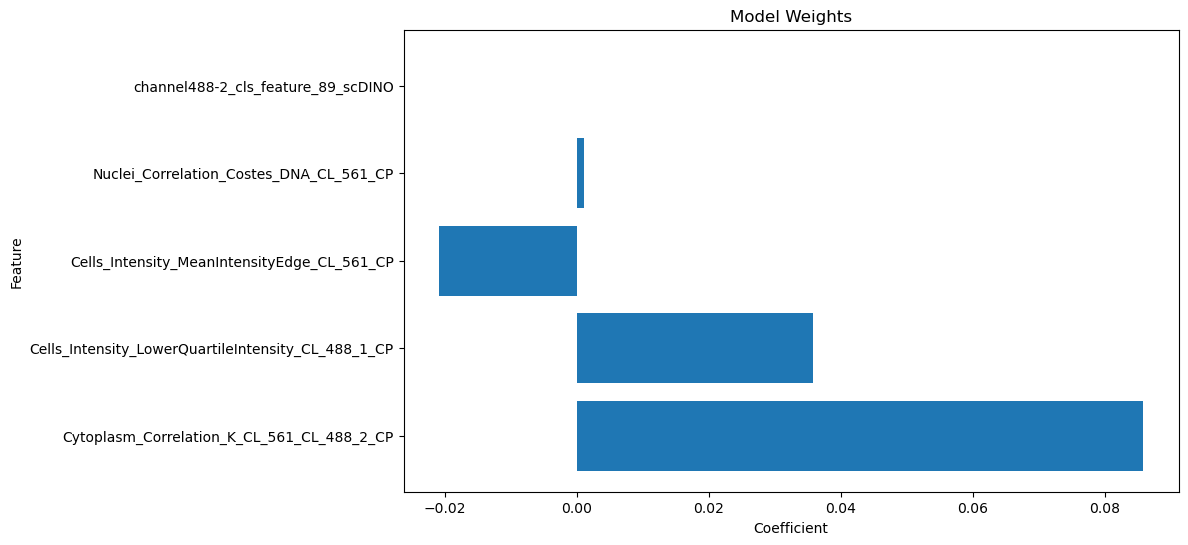

In [4]:
# plot the coefficients
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(coefs_df["feature"].head(5), coefs_df["coefficient"].head(5))
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Model Weights")
plt.show()

In [ ]:
model.estimators_[0].

In [9]:
model = joblib.load(all_features_model)
output_dict = {"predicted_column": [], "feature": [], "coefficient": []}
for est, predicted_column_name in zip(model.estimators_, terminal_column_names):
    feature_names = est.feature_names_in_
    coefficients = est.coef_
    for feature, coefficient in zip(feature_names, coefficients):
        output_dict["predicted_column"].append(predicted_column_name)
        output_dict["feature"].append(feature)
        output_dict["coefficient"].append(coefficient)
df = pd.DataFrame(output_dict)
df

,predicted_column,feature,coefficient
0,Terminal_Cytoplasm_AreaShape_Area,Cells_AreaShape_Compactness_CP,0.0
1,Terminal_Cytoplasm_AreaShape_Area,Cells_AreaShape_Eccentricity_CP,0.0
2,Terminal_Cytoplasm_AreaShape_Area,Cells_AreaShape_Extent_CP,-0.0
3,Terminal_Cytoplasm_AreaShape_Area,Cells_AreaShape_FormFactor_CP,-0.0
4,Terminal_Cytoplasm_AreaShape_Area,Cells_AreaShape_MajorAxisLength_CP,0.0
...,...,...,...
1226395,Terminal_Nuclei_Texture_SumAverage_DNA_3_01_256,channel_DNA_cls_feature_96_scDINO,-0.0
1226396,Terminal_Nuclei_Texture_SumAverage_DNA_3_01_256,channel_DNA_cls_feature_97_scDINO,-0.0
1226397,Terminal_Nuclei_Texture_SumAverage_DNA_3_01_256,channel_DNA_cls_feature_98_scDINO,0.0
1226398,Terminal_Nuclei_Texture_SumAverage_DNA_3_01_256,channel_DNA_cls_feature_99_scDINO,0.0


In [11]:
df.head()

,predicted_column,feature,coefficient
0,Terminal_Cytoplasm_AreaShape_Area,Cells_AreaShape_Compactness_CP,0.0
1,Terminal_Cytoplasm_AreaShape_Area,Cells_AreaShape_Eccentricity_CP,0.0
2,Terminal_Cytoplasm_AreaShape_Area,Cells_AreaShape_Extent_CP,-0.0
3,Terminal_Cytoplasm_AreaShape_Area,Cells_AreaShape_FormFactor_CP,-0.0
4,Terminal_Cytoplasm_AreaShape_Area,Cells_AreaShape_MajorAxisLength_CP,0.0


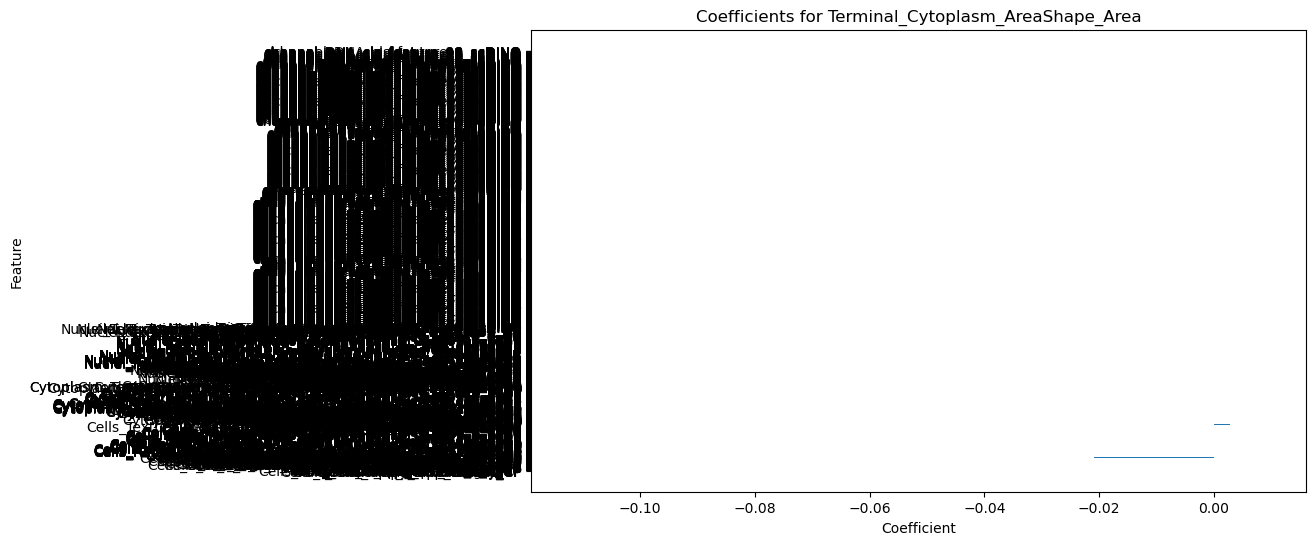

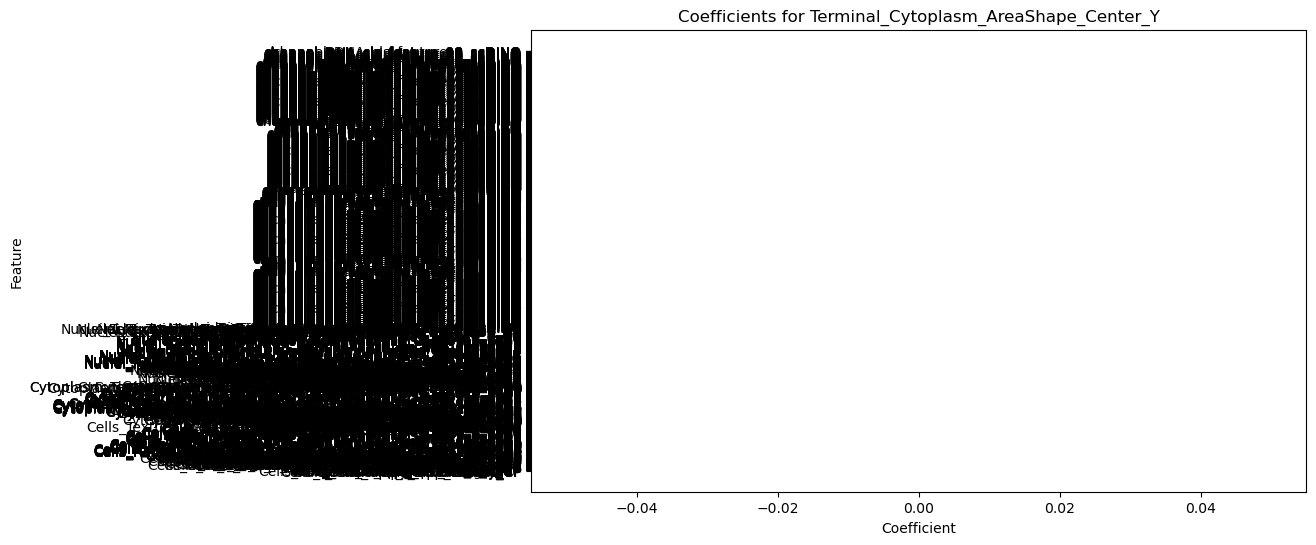

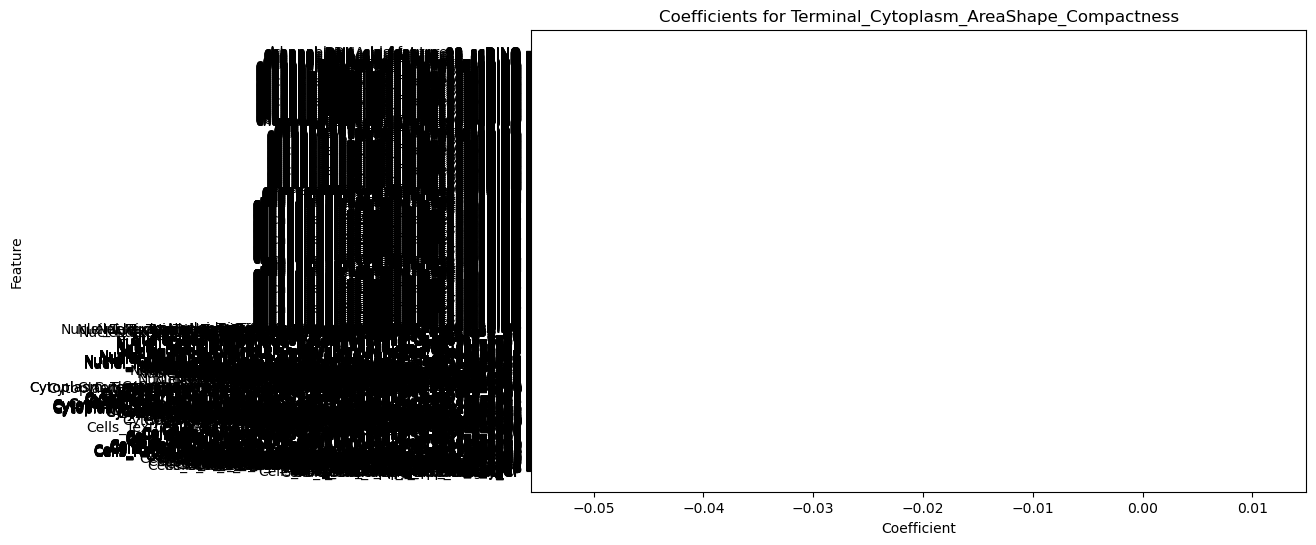

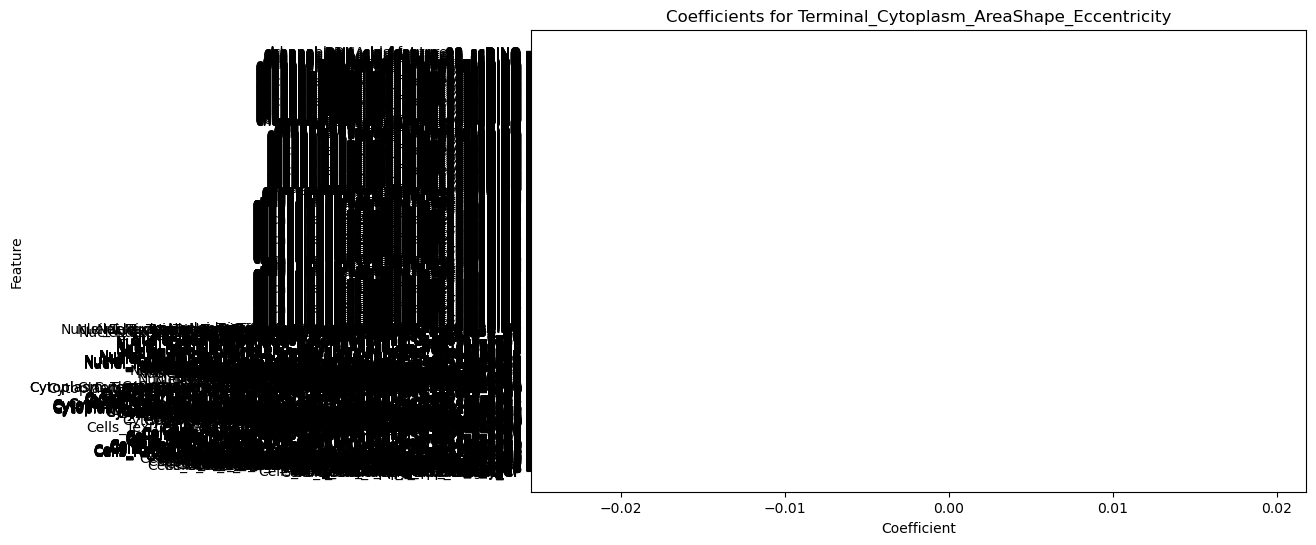

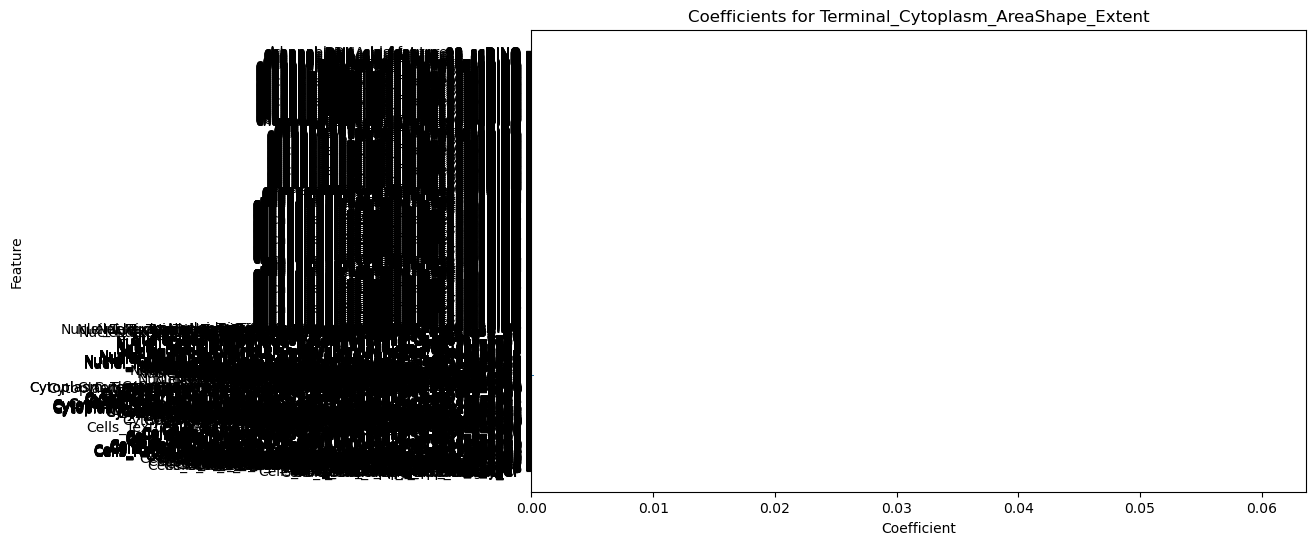

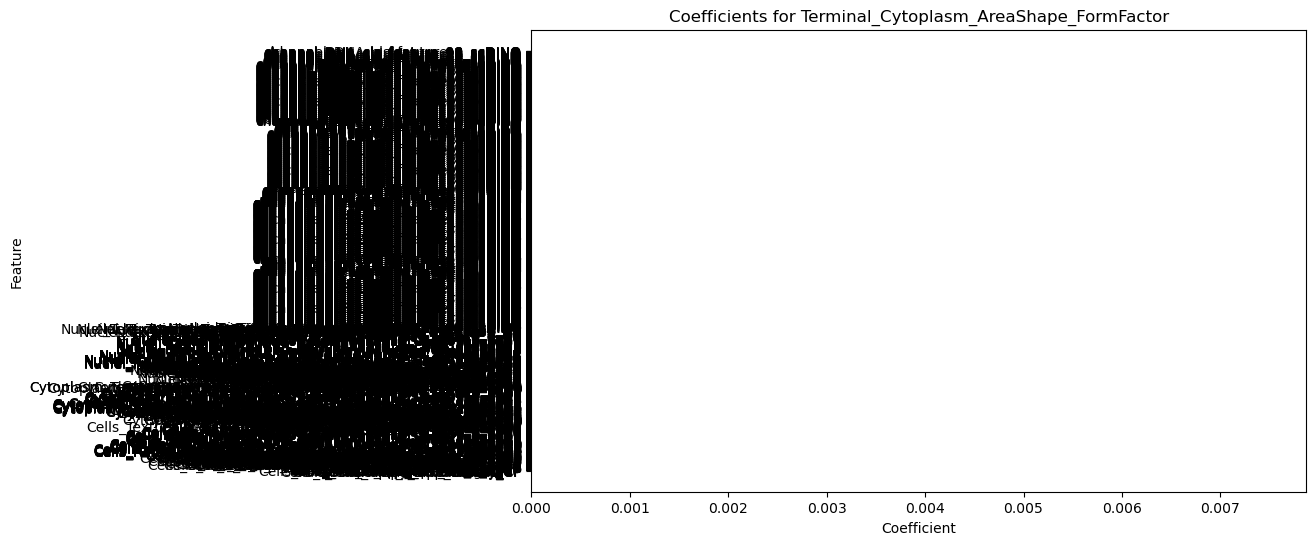

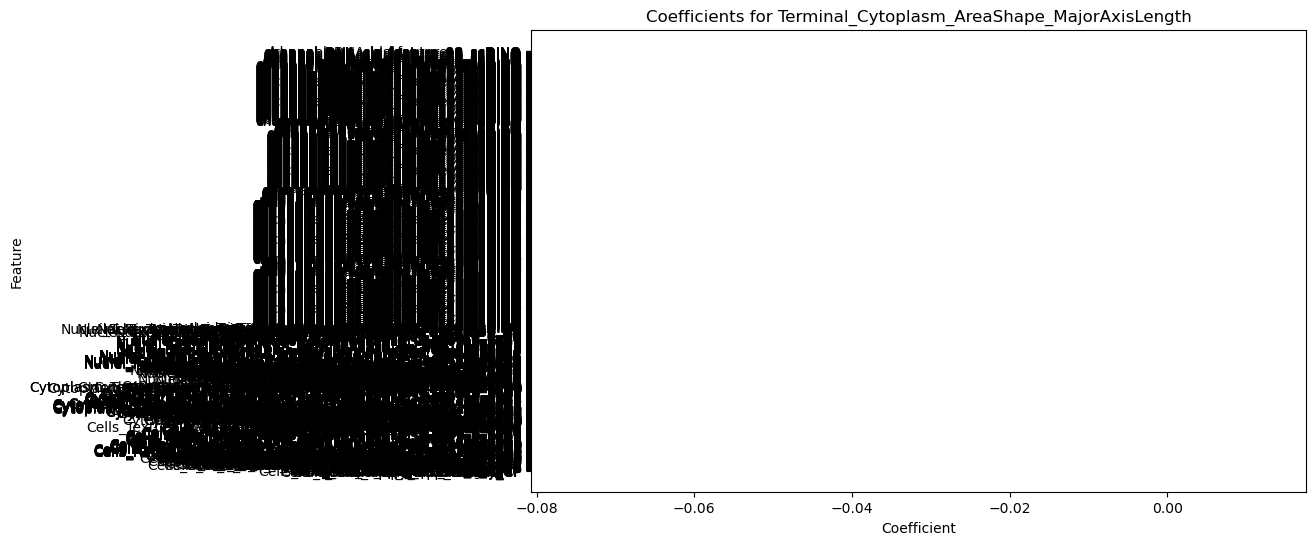

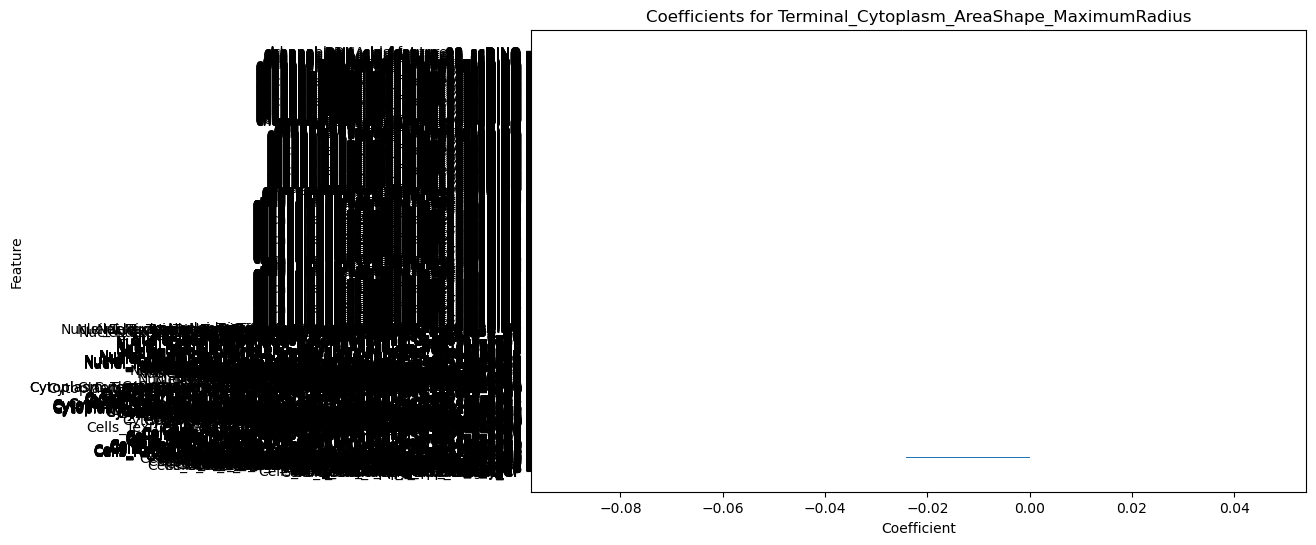

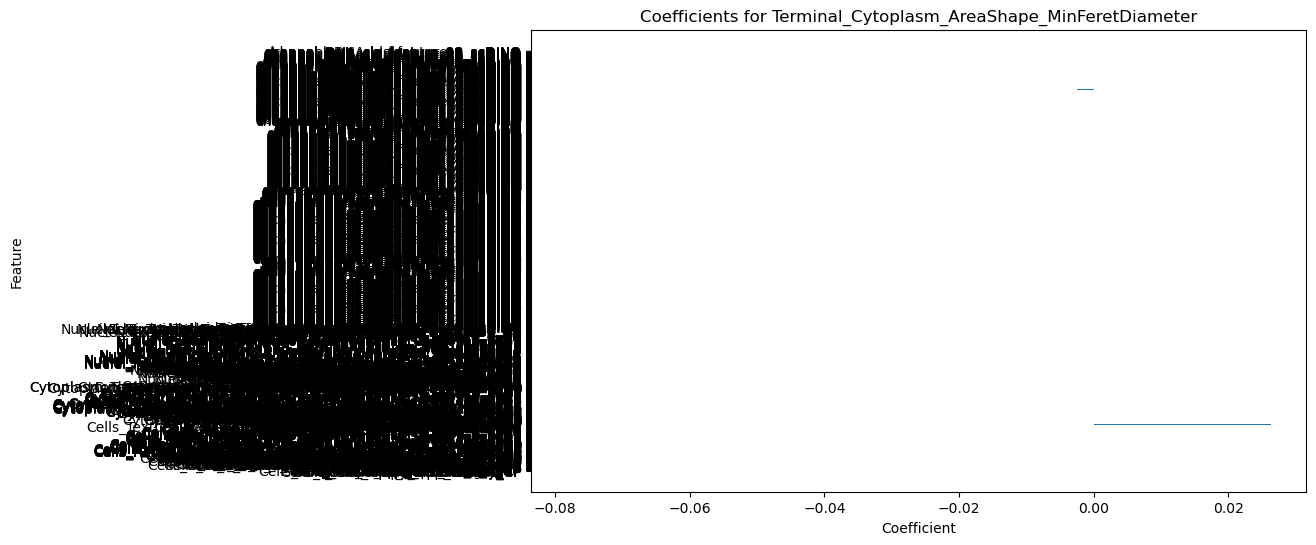

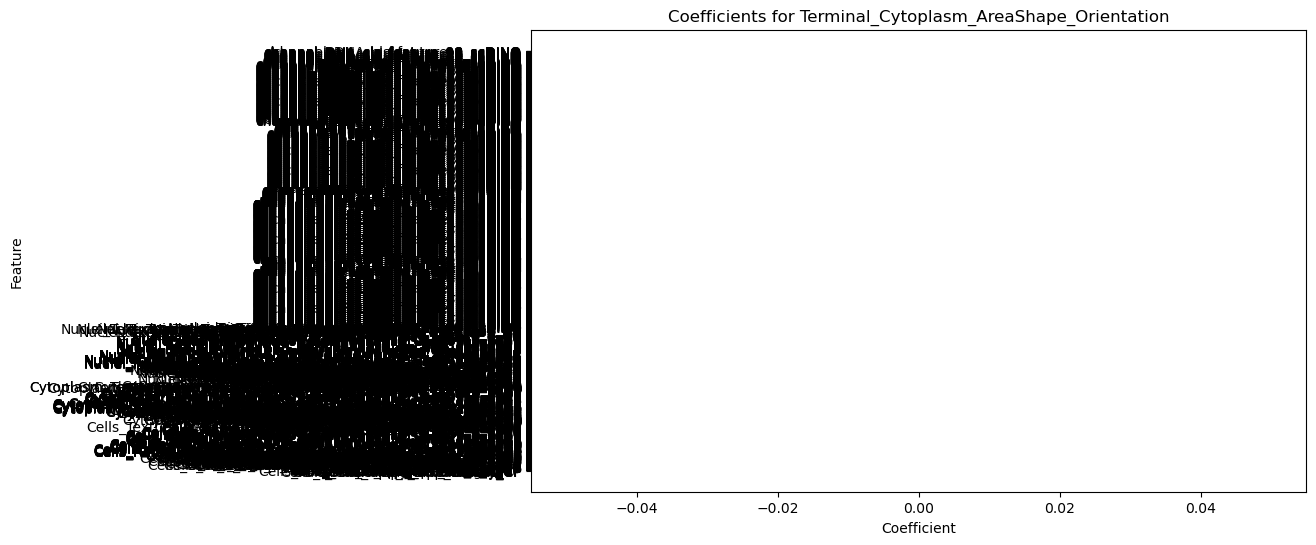

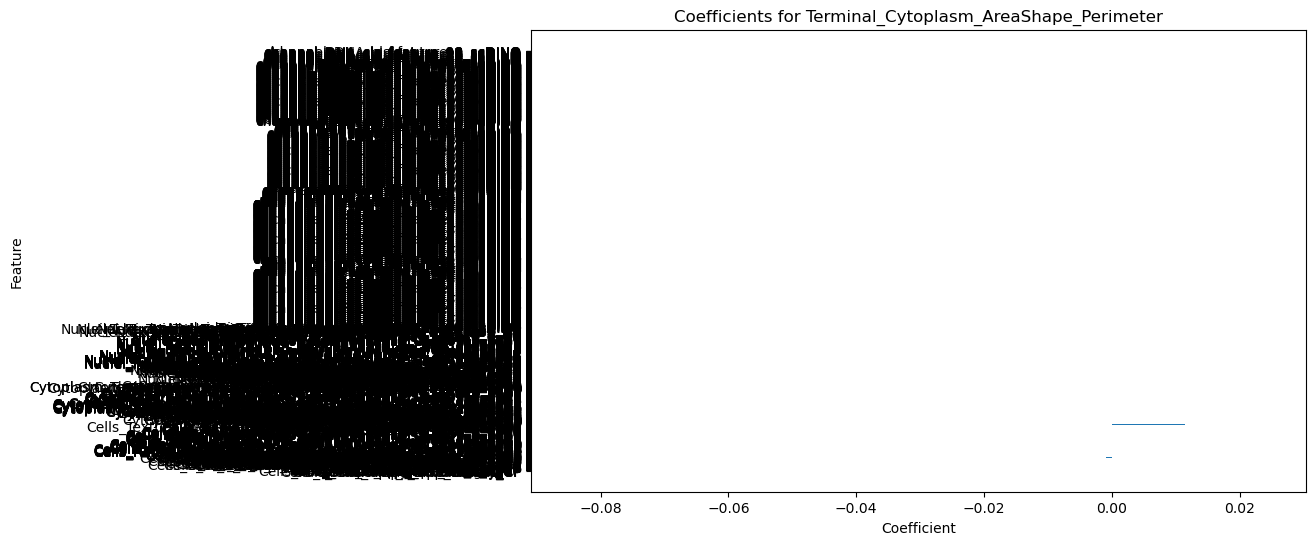

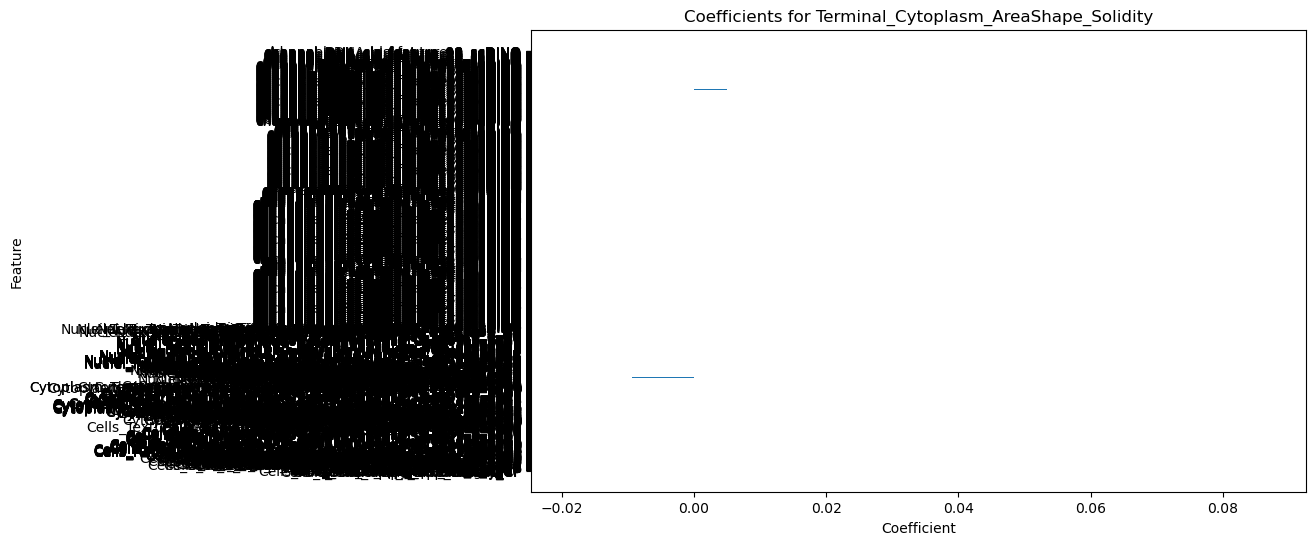

KeyboardInterrupt: 

In [12]:
# plot the df to show all coefficients per predicted column
import matplotlib.pyplot as plt

for predicted_column in df["predicted_column"].unique():
    plt.figure(figsize=(10, 6))
    subset = df[df["predicted_column"] == predicted_column]
    plt.barh(subset["feature"], subset["coefficient"])
    plt.xlabel("Coefficient")
    plt.ylabel("Feature")
    plt.title(f"Coefficients for {predicted_column}")
    plt.show()